In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=123)

In [16]:
def klein_bottle_R4(n=200):
    # Parameters
    R = 2.0 # large radius
    r = 1.0 # small radius

    # Random generation
    u = rng.uniform(low=0, high=2*np.pi, size=n)
    v = rng.uniform(low=0, high=2*np.pi, size=n)

    # Parametrization
    x = (R + r * np.cos(u)) * np.cos(v)
    y = (R + r * np.cos(u)) * np.sin(v)
    z =  r * np.sin(u) * np.cos(v / 2)
    w =  r * np.sin(u) * np.sin(v / 2)

    return np.column_stack([x, y, z, w])

def klein_bottle_noisy(n=200,sigma=1):
    points = klein_bottle_R4(n=200)

    mean = np.zeros(4)
    cov = np.eye(4) * (sigma^2)
    noise = rng.multivariate_normal(mean,cov,size=n)
    return points + noise

In [ ]:
# Visualisation 
fig, ax = p

In [ ]:


#Visualization
def project_R4_to_R3(X):
    """
    Smooth deterministic projection from R^4 to R^3.
    Combines z and w coordinates to preserve structure.
    """
    x = X[:,0]
    y = X[:,1]
    z = X[:,2] + X[:,3]
    return np.column_stack([x, y, z])

# Generate data
X_noisy = klein_bottle_R4_noisy(n=20, sigma=0.1)
X_proj = project_R4_to_R3(X_noisy)

# Extract coordinates
x, y, z = X_proj[:,0], X_proj[:,1], X_proj[:,2]

# Interactive 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(size=2, color=z, colorscale='Viridis')
)])

fig.update_layout(
    title="Noisy 4D Klein Bottle Projected to 3D",
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z')
)

fig.show()

/Users/tombourdareau/miniconda3/envs/tda/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning:

The input point cloud has more columns than rows; did you mean to transpose?



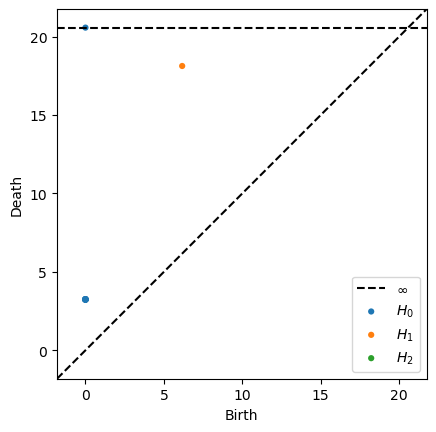

In [25]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
X= klein_bottle_R4(20)


result = ripser(X, maxdim=2)      # compute H0, H1, H2
diagrams_clean = result['dgms']

plot_diagrams(diagrams_clean, show=True)

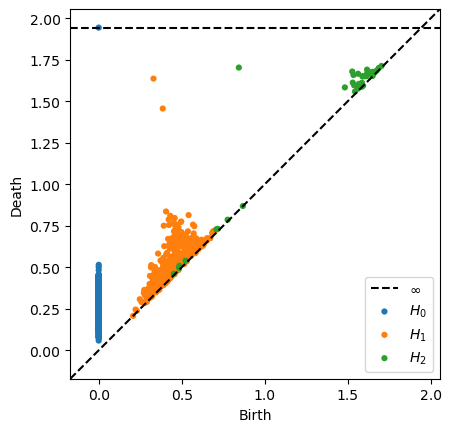

In [36]:
X_noisy = klein_bottle_R4_noisy(n=30, sigma=0.1)

result = ripser(X_noisy, maxdim=2)      # compute H0, H1, H2
diagrams = result['dgms']

plot_diagrams(diagrams, show=True)

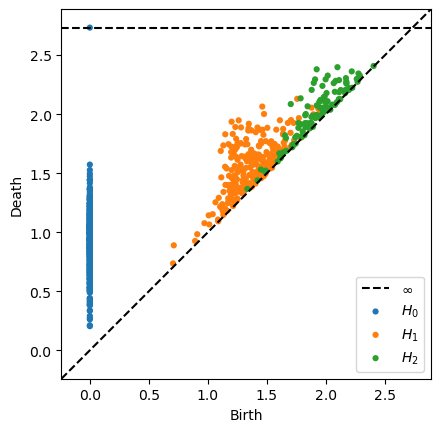

In [31]:
#Bounding box 
x_min,x_max = [None]*4,[None]*4
for i in range(4):
    x_min[i], x_max[i] = X[:,i].min(),X[:,i].max()

n_point=400
pure_noise = np.random.uniform(
    low=x_min,
    high=x_max,
    size=(n_point,4)
)

result = ripser(pure_noise,maxdim=2)
diagrams_uni = result['dgms']

plot_diagrams(diagrams_uni,show=True)

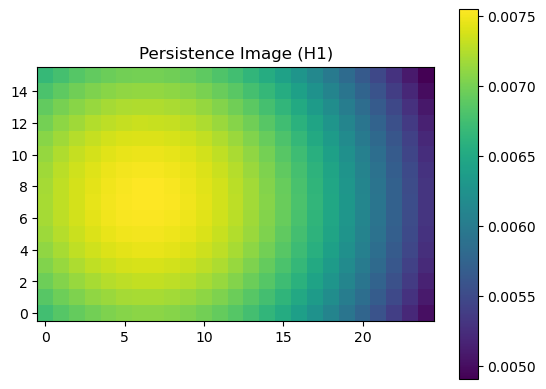

In [32]:
from persim import PersistenceImager

pimager = PersistenceImager(pixel_size=0.05)
pimager.fit(diagrams[1])

# The `transform()` method can then be called on one or more (*,2) numpy arrays
# to generate persistence images from diagrams.
img = pimager.transform(diagrams[1])

plt.imshow(img, origin='lower')
plt.colorbar()
plt.title("Persistence Image (H1)")
plt.show()

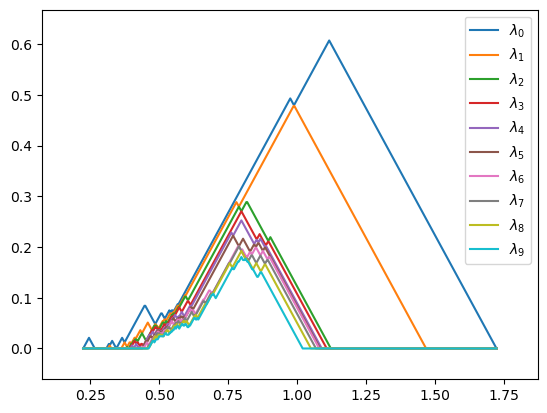

In [28]:
from persim import PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple

pla = PersLandscapeApprox(dgms=diagrams,hom_deg=1)
ax = plot_landscape_simple(pla, depth_range=range(10))

/Users/tombourdareau/miniconda3/envs/tda/lib/python3.13/site-packages/ripser/ripser.py:253: UserWarning:

The input point cloud has more columns than rows; did you mean to transpose?



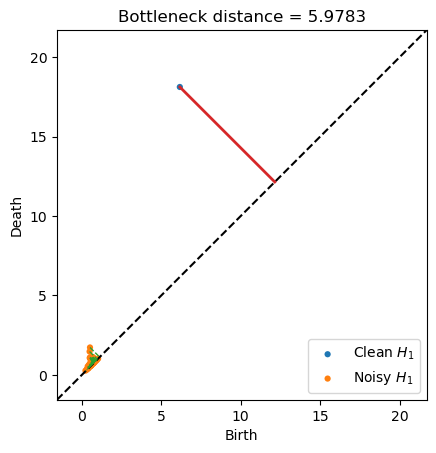

In [29]:
from persim import bottleneck, bottleneck_matching

dgm_clean = ripser(X)['dgms'][1]
dgm_noisy = ripser(X_noisy)['dgms'][1]

# The bottleneck of the matching is shown as a red line,
# while the other pairs in the perfect matching which are less than the diagonal are shown as green lines
# (NOTE: There may be many possible matchings with the minimum bottleneck, and this returns an arbitrary one)
distance_bottleneck, matching = bottleneck(dgm_clean, dgm_noisy, matching=True)
bottleneck_matching(
    dgm_clean, dgm_noisy, matching,
    labels=['Clean $H_1$', 'Noisy $H_1$']
)
plt.title(f"Bottleneck distance = {distance_bottleneck:0.4f}",)
plt.show()

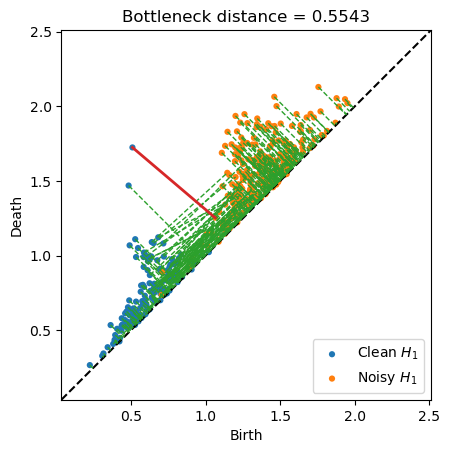

In [33]:
dgm_noisy = ripser(X_noisy)['dgms'][1]
dgm_uni = ripser(pure_noise)['dgms'][1]

# The bottleneck of the matching is shown as a red line,
# while the other pairs in the perfect matching which are less than the diagonal are shown as green lines
# (NOTE: There may be many possible matchings with the minimum bottleneck, and this returns an arbitrary one)
distance_bottleneck, matching = bottleneck(dgm_noisy, dgm_uni, matching=True)
bottleneck_matching(
    dgm_noisy, dgm_uni, matching,
    labels=['Clean $H_1$', 'Noisy $H_1$']
)
plt.title(f"Bottleneck distance = {distance_bottleneck:0.4f}",)
plt.show()